In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from scipy.signal import find_peaks

# Orthogonal Polarizer axes - analysis 

In [122]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_ortogonal.csv')
I_med = medicion['voltaje']-0.00194
theta = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.003218,0
1,0.006484,10
2,0.011864,20
3,0.014984,30
4,0.014939,40


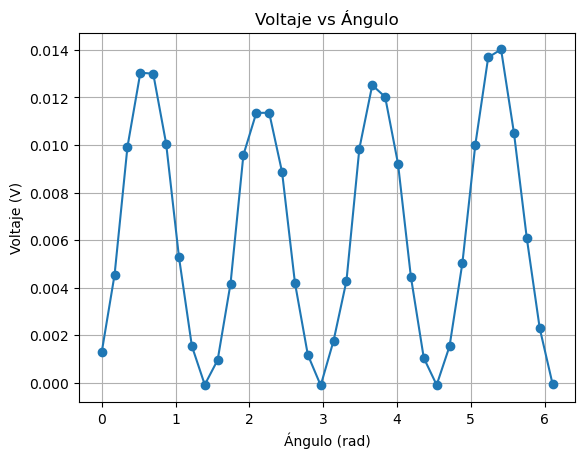

In [123]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta, I_med, 'o-')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [124]:
#we calculate the first minimum
min_idx = None

for i in range(1, len(I_med)-1):
    if I_med[i] < I_med[i-1] and I_med[i] < I_med[i+1]:
        min_idx = i
        break

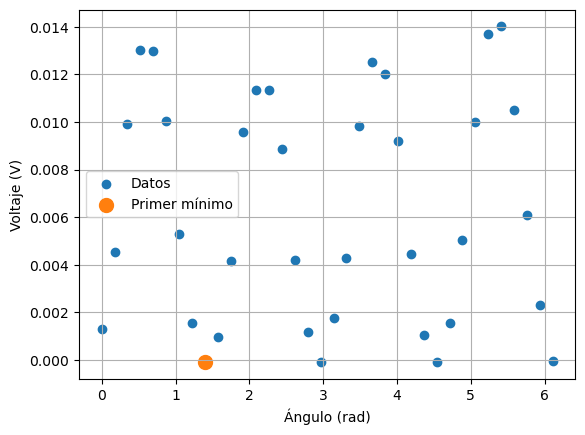

In [ ]:
#we make sure we are defining correctly the lowest voltage
import matplotlib.pyplot as plt

plt.scatter(theta, I_med, label="Datos")

# marcar el mínimo
plt.scatter(theta[min_idx], I_med[min_idx],
            marker='o', s=100, label="Primer mínimo")

plt.xlabel("Ángulo (rad)")
plt.ylabel("Voltaje (V)")
plt.legend()
plt.grid()
plt.show()

In [126]:
print(min_idx)

8


In [127]:
theta = theta - theta[min_idx]

In [ ]:
#finally 
theta = theta[min_idx:].reset_index(drop=True)
I_med = I_med[min_idx:].reset_index(drop=True)

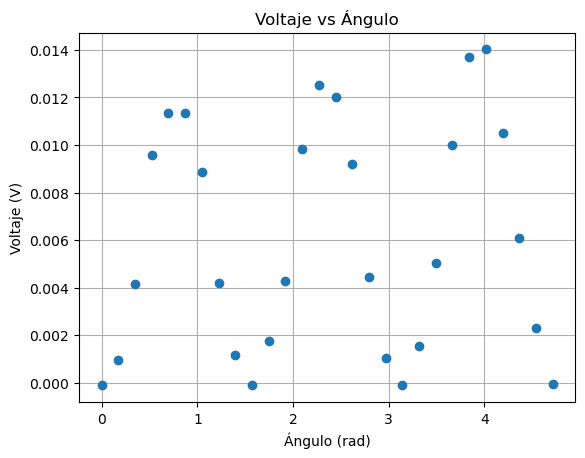

In [129]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta, I_med, 'o')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [ ]:
#--- estimate S0 --- and normalize voltaje 
# # --- Identify peaks in the voltage data to select the mean as the normalization factor --- 
peaks_volt = find_peaks(I_med)[0] 
peaks_angle = theta[peaks_volt] 
norm_number = I_med[peaks_volt].mean() 
display(f'Normalization number: {norm_number}') 
I_med = I_med / norm_number

'Normalization number: 0.012632266666666664'

In [131]:
S0 = np.max(I_med)
print(f'S0: {S0}')

S0: 1.1099829009309494


S0 = 1.1099829009309494
S1 = -1.109982900930849
S2 = -0.007566439008365308
S3 = 0.24156898779963984

Deltas:
d1 = 2.5212490199541158
d2 = 3.6201039304921103
d3 = 3.602519003634915
d4 = 1.5707963267948966

DOP = 1.0234308092598245


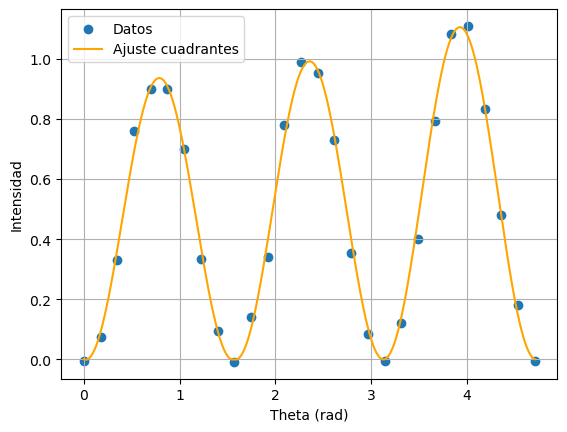

In [132]:

# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return model(theta, S1, S2, S3, d1, d2, d3, d4) - I_med

# --- initial conditions ---
initial_guess = [
    0.1*S0,  # S1
    0.1*S0,  # S2
    0.1*S0,  # S3
    np.pi/2, np.pi/2, np.pi/2, np.pi/2  # deltas
]

# --- bounds (KEY for stability) ---
lower_bounds = [
    -S0, -S0, -S0,
    0, 0, 0, 0
]

upper_bounds = [
    S0, S0, S0,
    2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi
]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

print("S0 =", S0)
print("S1 =", S1_fit)
print("S2 =", S2_fit)
print("S3 =", S3_fit)

print("\nDeltas:")
print("d1 =", d1_fit)
print("d2 =", d2_fit)
print("d3 =", d3_fit)
print("d4 =", d4_fit)

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0
print("\nDOP =", DOP)

# --- fitted curve ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- graph ---
plt.scatter(theta, I_med, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

In [133]:
#we can also plot the points on the Poincare sphere

def plot_poincare_sphere(ax, s_fit):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    ax.scatter(s_fit[0], s_fit[1], s_fit[2], s=90, label="Fitted point")
    ax.plot([0, s_fit[0]], [0, s_fit[1]], [0, s_fit[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()



[-1.         -0.00681672  0.21763307]


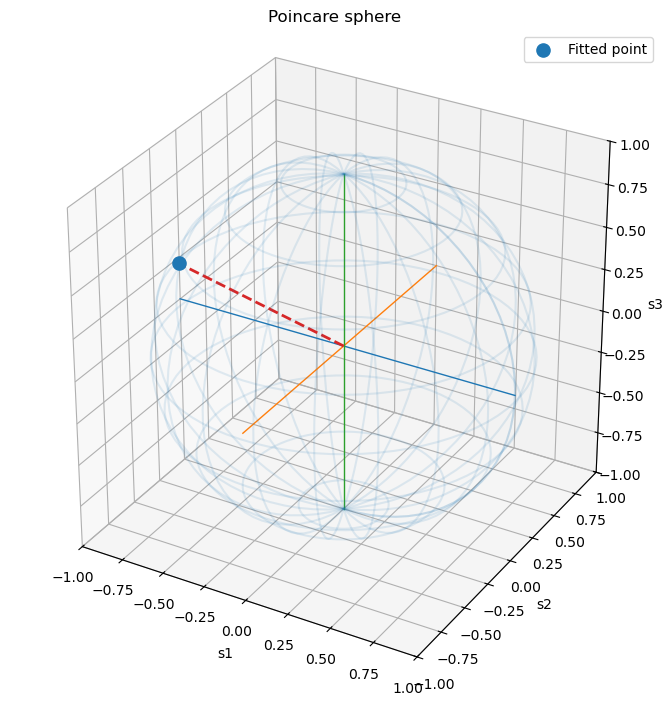

In [134]:
fig_new = plt.figure(figsize=(7, 7))
s_fit=np.array([S1_fit/S0 , S2_fit/S0 , S3_fit/S0 ] )
print(s_fit)
ax_new = fig_new.add_subplot(111, projection='3d')
plot_poincare_sphere(ax_new,  s_fit)
plt.tight_layout()
plt.show()

# Parallel polarizer axes - Analysis

In [135]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_paralelo.csv')
I_med = medicion['voltaje']-0.00194
theta = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.069970,0
1,0.062231,10
2,0.053607,20
3,0.039862,30
4,0.034066,40


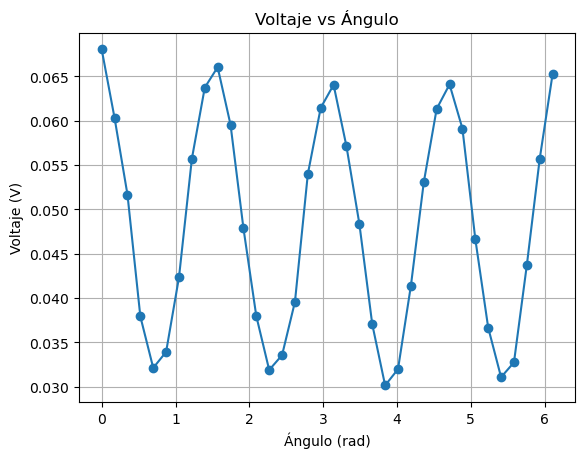

In [136]:
#we plot the data to see if it looks like a sinusoidal function, as we expect
plt.plot(theta, I_med, 'o-')
plt.xlabel('Ángulo (rad)') 
plt.ylabel('Voltaje (V)')
plt.title('Voltaje vs Ángulo')
plt.grid()
plt.show()

In [137]:
# --- estimate S0 --- and normalize voltaje
# --- Identify peaks in the voltage data to select the mean as the normalization factor ---
peaks_volt = find_peaks(medicion['voltaje'])[0]
peaks_angle = theta[peaks_volt]
norm_number = medicion['voltaje'][peaks_volt].mean()
display(f'Normalization number: {norm_number}')

I_med = I_med / norm_number


'Normalization number: 0.0666576'

In [ ]:

S0 = np.max(I_med)
print(f'S0: {S0}')

S0: 1.1099829009309494


S0 = 1.0205827992606997
S1 = 0.9394488259348048
S2 = -0.1562695820240695
S3 = 0.008996705688669672

Deltas:
d1 = 1.6074862115260447
d2 = 1.677245034739534
d3 = 1.6863682370726507
d4 = 1.6745540900472147

DOP = 0.9331920123957939


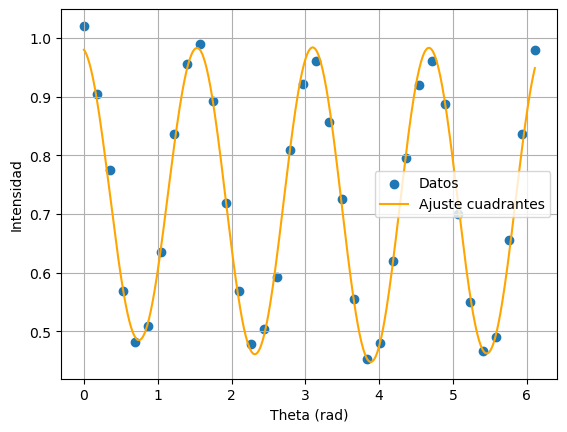

In [139]:
# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return model(theta, S1, S2, S3, d1, d2, d3, d4) - I_med

# --- initial conditions ---
initial_guess = [
    0.1*S0,  # S1
    0.1*S0,  # S2
    0.1*S0,  # S3
    np.pi/2, np.pi/2, np.pi/2, np.pi/2  # deltas
]

# --- bounds (KEY for stability) ---
lower_bounds = [
    -S0, -S0, -S0,
    0, 0, 0, 0
]

upper_bounds = [
    S0, S0, S0,
    2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi
]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

print("S0 =", S0)
print("S1 =", S1_fit)
print("S2 =", S2_fit)
print("S3 =", S3_fit)

print("\nDeltas:")
print("d1 =", d1_fit)
print("d2 =", d2_fit)
print("d3 =", d3_fit)
print("d4 =", d4_fit)

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0
print("\nDOP =", DOP)

# --- fitted curve ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- graph ---
plt.scatter(theta, I_med, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

[ 0.92050231 -0.15311799  0.00881526]


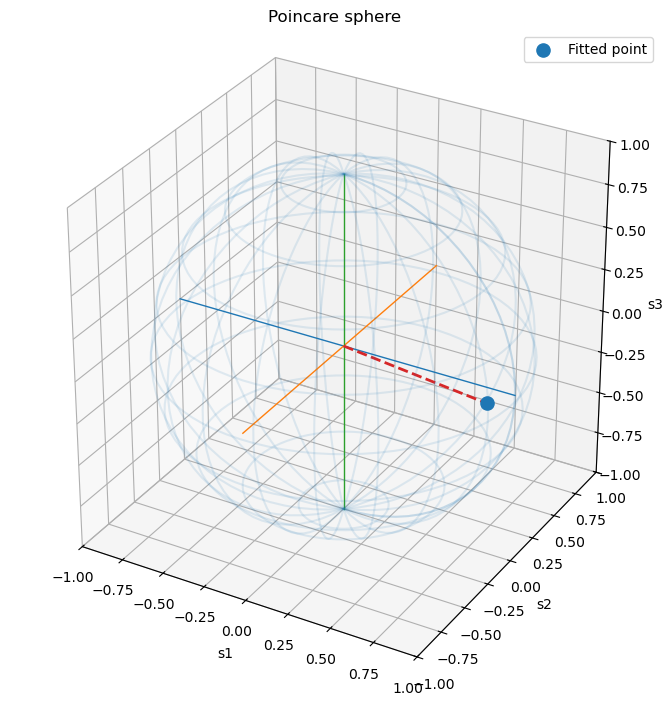

In [140]:
fig_new = plt.figure(figsize=(7, 7))
s_fit=np.array([S1_fit/S0, S2_fit/S0, S3_fit/S0]  )
print(s_fit)
ax_new = fig_new.add_subplot(111, projection='3d')
plot_poincare_sphere(ax_new,  s_fit)
plt.tight_layout()
plt.show()

# Comparison of both polarizations 

In [141]:
def plot_poincare_sphere(ax, s_points):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- plot de múltiples puntos ---
    for i, s in enumerate(s_points):
        ax.scatter(s[0], s[1], s[2], s=90, label=f"Point {i+1}")
        ax.plot([0, s[0]], [0, s[1]], [0, s[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

In [142]:
s1=np.array([-1. ,        -0.00681672,  0.21763307] )
s2=np.array([ 0.92050231, -0.15311799,  0.00881526] )
s3=np.array([-0.82727437,  0.67022515 , 0.02815319])

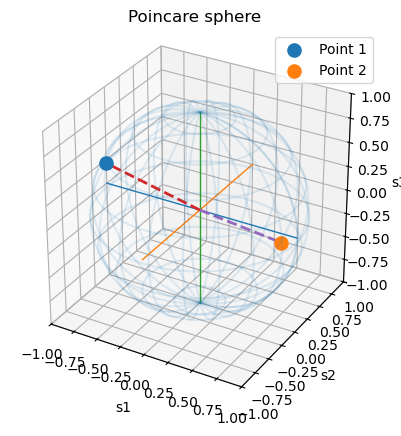

In [143]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_poincare_sphere(ax, [s1, s2])

plt.show()

# Errors an graphs

## Orthogonal

In [152]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_ortogonal.csv')
I_med = medicion['voltaje']-0.00194
theta = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.003218,0
1,0.006484,10
2,0.011864,20
3,0.014984,30
4,0.014939,40


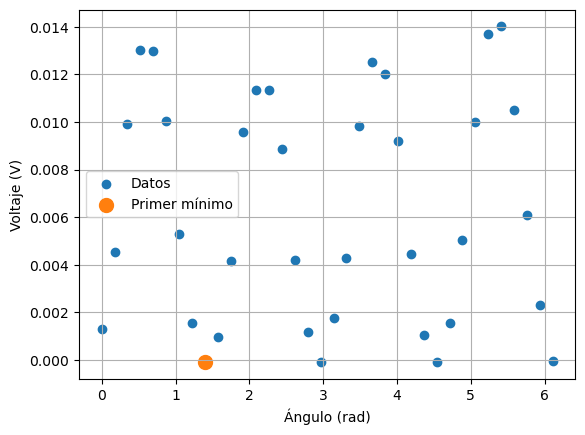

'Normalization number: 0.012632266666666664'

In [153]:
#we calculate the first minimum
min_idx = None

for i in range(1, len(I_med)-1):
    if I_med[i] < I_med[i-1] and I_med[i] < I_med[i+1]:
        min_idx = i
        break
    
#we make sure we are defining correctly the lowest voltage
import matplotlib.pyplot as plt

plt.scatter(theta, I_med, label="Datos")

# marcar el mínimo
plt.scatter(theta[min_idx], I_med[min_idx],
            marker='o', s=100, label="Primer mínimo")

plt.xlabel("Ángulo (rad)")
plt.ylabel("Voltaje (V)")
plt.legend()
plt.grid()
plt.show()

#finally 
theta = theta[min_idx:].reset_index(drop=True)
I_med = I_med[min_idx:].reset_index(drop=True)

#--- estimate S0 --- and normalize voltaje 
# # --- Identify peaks in the voltage data to select the mean as the normalization factor --- 
peaks_volt = find_peaks(I_med)[0] 
peaks_angle = theta[peaks_volt] 
norm_number = I_med[peaks_volt].mean() 
display(f'Normalization number: {norm_number}') 
I_med = I_med / norm_number

In [154]:
S0=np.max(I_med)

In [149]:
#errors


theta_err = np.deg2rad(2)     

V_div=0.005 #V
V_full_scale = 8 * V_div  
res_err = V_full_scale / 256

I_err = np.sqrt((0.03 * I_med)**2 + res_err**2)
I_err = np.abs(I_err)



S0 = 1.1099829009309494
S1 = -0.9049185208193028 ± 0.013182778996638054
S2 = 0.6977388179204971 ± 0.03558104975192522
S3 = -0.116531303258006 ± 0.06016560385626537

Deltas:
d1 = 2.8198732507181696 ± 0.40802608297995213
d2 = 2.238222808416691 ± 0.10158721467148006
d3 = 4.0820303575534105 ± 0.09105615409337237
d4 = 3.5103674894305463 ± 0.39291065863866587

DOP = 1.0347964300990826 ± 0.02229292696062


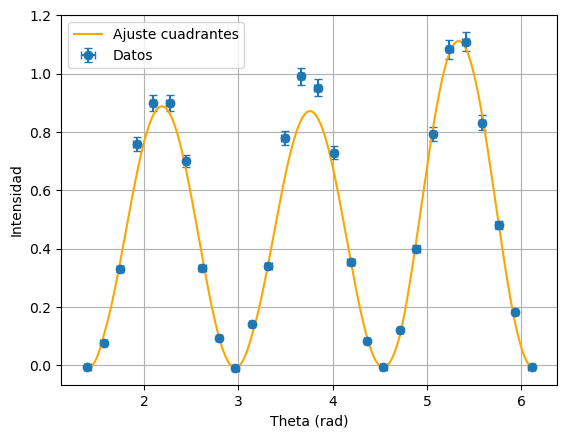

In [157]:

# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals con pesos ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return (model(theta, S1, S2, S3, d1, d2, d3, d4) - I_med) / I_err

# --- initial conditions ---
initial_guess = [
    0.1*S0,
    0.1*S0,
    0.1*S0,
    np.pi/2, np.pi/2, np.pi/2, np.pi/2
]

# --- bounds ---
lower_bounds = [-S0, -S0, -S0, 0, 0, 0, 0]
upper_bounds = [ S0,  S0,  S0, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

# --- errores de parámetros ---
J = result.jac
cov = np.linalg.inv(J.T @ J) * np.sum(result.fun**2) / (len(I_med) - len(result.x))
param_errors = np.sqrt(np.diag(cov))

S1_err, S2_err, S3_err, d1_err, d2_err, d3_err, d4_err = param_errors

# --- resultados ---
print("S0 =", S0)
print(f"S1 = {S1_fit} ± {S1_err}")
print(f"S2 = {S2_fit} ± {S2_err}")
print(f"S3 = {S3_fit} ± {S3_err}")

print("\nDeltas:")
print(f"d1 = {d1_fit} ± {d1_err}")
print(f"d2 = {d2_fit} ± {d2_err}")
print(f"d3 = {d3_fit} ± {d3_err}")
print(f"d4 = {d4_fit} ± {d4_err}")

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0

DOP_err = (1 / S0) * np.sqrt(
    (S1_fit * S1_err)**2 +
    (S2_fit * S2_err)**2 +
    (S3_fit * S3_err)**2
) / np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2)

print(f"\nDOP = {DOP} ± {DOP_err}")

# --- fitted curve ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- gráfico con errores ---
plt.errorbar(theta, I_med, yerr=I_err, xerr=theta_err,
             fmt='o', capsize=3, label="Datos")

plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

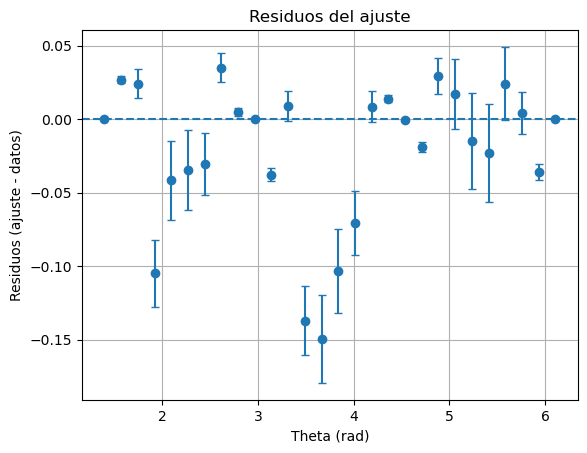

In [158]:
residuos = model(theta, S1_fit, S2_fit, S3_fit,
                 d1_fit, d2_fit, d3_fit, d4_fit) - I_med

plt.errorbar(theta, residuos, yerr=I_err, fmt='o', capsize=3)

plt.axhline(0, linestyle='--')

plt.xlabel("Theta (rad)")
plt.ylabel("Residuos (ajuste - datos)")
plt.title("Residuos del ajuste")

plt.grid()
plt.show()

In [161]:
# grados de libertad
N = len(I_med)
p = len(result.x)
dof = N - p

# chi cuadrado
from scipy.stats import chi2
chi2_val = np.sum(result.fun**2)

# p-valor
p_value = 1 - chi2.cdf(chi2_val, dof)

print(f"Chi^2 = {chi2_val}")
print(f"grados de libertad = {dof}")
print(f"p-valor = {p_value}")

Chi^2 = 463.7075615244891
grados de libertad = 21
p-valor = 0.0


In [162]:
# --- vector de Stokes normalizado (Poincaré) ---
s1 = S1_fit / S0
s2 = S2_fit / S0
s3 = S3_fit / S0

# --- errores ---
s1_err = S1_err / S0
s2_err = S2_err / S0
s3_err = S3_err / S0

print("\nVector de Poincaré:")
print(f"s1 = {s1} ± {s1_err}")
print(f"s2 = {s2} ± {s2_err}")
print(f"s3 = {s3} ± {s3_err}")


Vector de Poincaré:
s1 = -0.8152544692898802 ± 0.011876560427716117
s2 = 0.628603213018236 ± 0.03205549357749852
s3 = -0.10498477333323827 ± 0.05420408170774893


## Parallel

In [164]:
medicion = pd.read_csv('Measurements\\medicion_manual_polarimetro_paralelo.csv')
I_med = medicion['voltaje']-0.00194
theta = medicion['angulo']*np.pi/180
medicion.head()

,voltaje,angulo
0,0.069970,0
1,0.062231,10
2,0.053607,20
3,0.039862,30
4,0.034066,40


In [165]:
# --- estimate S0 --- and normalize voltaje
# --- Identify peaks in the voltage data to select the mean as the normalization factor ---
peaks_volt = find_peaks(medicion['voltaje'])[0]
peaks_angle = theta[peaks_volt]
norm_number = medicion['voltaje'][peaks_volt].mean()
display(f'Normalization number: {norm_number}')

I_med = I_med / norm_number
S0 = np.max(I_med)
print(f'S0: {S0}')

'Normalization number: 0.0666576'

S0: 1.0205827992606997


In [166]:
#errors


theta_err = np.deg2rad(2)     

V_div=0.005 #V
V_full_scale = 8 * V_div  
res_err = V_full_scale / 256

I_err = np.sqrt((0.03 * I_med)**2 + res_err**2)
I_err = np.abs(I_err)


S0 = 1.0205827992606997
S1 = 0.9371172319491584 ± 0.013281677560041973
S2 = -0.14981049929897122 ± 0.01577238966297911
S3 = -0.01312818573183922 ± 0.04517770199301829

Deltas:
d1 = 1.642710050514748 ± 0.05439641440084592
d2 = 1.6453120052957522 ± 0.05461017167170642
d3 = 1.7103528391023284 ± 0.05403008736012412
d4 = 1.653225292955498 ± 0.05424373605723658

DOP = 0.9299657769171737 ± 0.013093238764047358


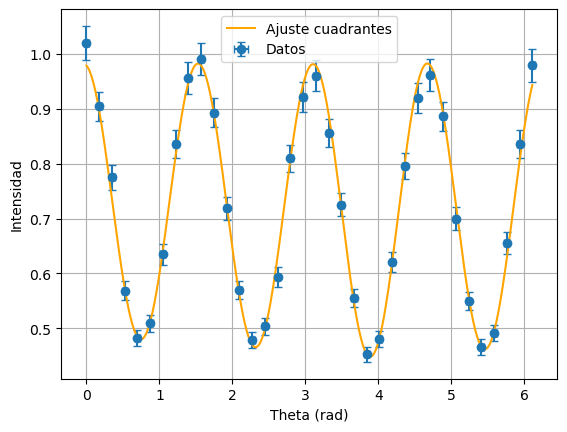

In [167]:

# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals con pesos ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return (model(theta, S1, S2, S3, d1, d2, d3, d4) - I_med) / I_err

# --- initial conditions ---
initial_guess = [
    0.1*S0,
    0.1*S0,
    0.1*S0,
    np.pi/2, np.pi/2, np.pi/2, np.pi/2
]

# --- bounds ---
lower_bounds = [-S0, -S0, -S0, 0, 0, 0, 0]
upper_bounds = [ S0,  S0,  S0, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

# --- errores de parámetros ---
J = result.jac
cov = np.linalg.inv(J.T @ J) * np.sum(result.fun**2) / (len(I_med) - len(result.x))
param_errors = np.sqrt(np.diag(cov))

S1_err, S2_err, S3_err, d1_err, d2_err, d3_err, d4_err = param_errors

# --- resultados ---
print("S0 =", S0)
print(f"S1 = {S1_fit} ± {S1_err}")
print(f"S2 = {S2_fit} ± {S2_err}")
print(f"S3 = {S3_fit} ± {S3_err}")

print("\nDeltas:")
print(f"d1 = {d1_fit} ± {d1_err}")
print(f"d2 = {d2_fit} ± {d2_err}")
print(f"d3 = {d3_fit} ± {d3_err}")
print(f"d4 = {d4_fit} ± {d4_err}")

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0

DOP_err = (1 / S0) * np.sqrt(
    (S1_fit * S1_err)**2 +
    (S2_fit * S2_err)**2 +
    (S3_fit * S3_err)**2
) / np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2)

print(f"\nDOP = {DOP} ± {DOP_err}")

# --- fitted curve ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- gráfico con errores ---
plt.errorbar(theta, I_med, yerr=I_err, xerr=theta_err,
             fmt='o', capsize=3, label="Datos")

plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

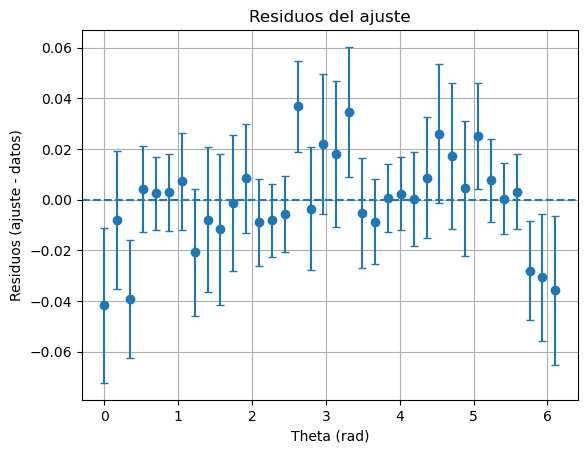

In [168]:
residuos = model(theta, S1_fit, S2_fit, S3_fit,
                 d1_fit, d2_fit, d3_fit, d4_fit) - I_med

plt.errorbar(theta, residuos, yerr=I_err, fmt='o', capsize=3)

plt.axhline(0, linestyle='--')

plt.xlabel("Theta (rad)")
plt.ylabel("Residuos (ajuste - datos)")
plt.title("Residuos del ajuste")

plt.grid()
plt.show()

In [169]:
# grados de libertad
N = len(I_med)
p = len(result.x)
dof = N - p

# chi cuadrado
from scipy.stats import chi2
chi2_val = np.sum(result.fun**2)

# p-valor
p_value = 1 - chi2.cdf(chi2_val, dof)

print(f"Chi^2 = {chi2_val}")
print(f"grados de libertad = {dof}")
print(f"p-valor = {p_value}")

Chi^2 = 22.437846232033483
grados de libertad = 29
p-valor = 0.8016179154269756


In [170]:
# --- vector de Stokes normalizado (Poincaré) ---
s1 = S1_fit / S0
s2 = S2_fit / S0
s3 = S3_fit / S0

# --- errores ---
s1_err = S1_err / S0
s2_err = S2_err / S0
s3_err = S3_err / S0

print("\nVector de Poincaré:")
print(f"s1 = {s1} ± {s1_err}")
print(f"s2 = {s2} ± {s2_err}")
print(f"s3 = {s3} ± {s3_err}")


Vector de Poincaré:
s1 = 0.9182177405184538 ± 0.013013816781610558
s2 = -0.14678916733408842 ± 0.01545429697071563
s3 = -0.012863420529279104 ± 0.0442665720270267


## Final Comparison with three points obteined

In [171]:
def plot_poincare_sphere(ax, s_points):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    # ejes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    # --- plot de múltiples puntos ---
    for i, s in enumerate(s_points):
        ax.scatter(s[0], s[1], s[2], s=90, label=f"Point {i+1}")
        ax.plot([0, s[0]], [0, s[1]], [0, s[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()

In [172]:
s1=np.array([-0.8152544692898802 ,         0.628603213018236,  -0.10498477333323827] )
s2=np.array([ 0.9182177405184538, -0.14678916733408842,  -0.012863420529279104] )
s3=np.array([-0.82727437,  0.67022515 , 0.02815319])

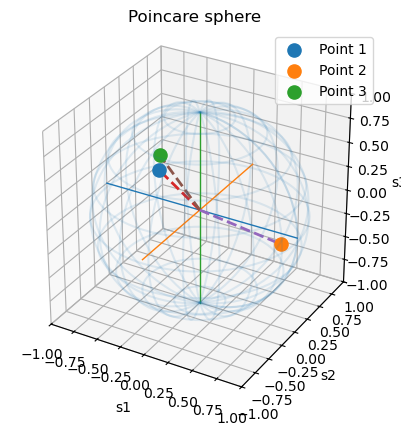

In [173]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_poincare_sphere(ax, [s1, s2, s3])

plt.show()